## DV1597 - Assignment 1

#### Mauritz Almgren   manz24@student.bth.se <br> Anton Maksymchuk Netterström   anmy24@student.bth.se

This code contains all the solutions for Q1-Q11.

The questions regard a dataset from SMHI where we will need to handle various data cleaning tasks as well as aggregating the data in various ways. We will then need to do some data analyses on this dataset and visualize it.

Question 1

Explain the data cleaning steps you consider for analyzing the provided dataset. You must motivate and describe why, how, and in which order you are going to apply the selected steps to the dataset. Note that you should consider applying your proposed data cleaning steps on the dataset to answer Q2-Q11 regardless of the questions’ order.

Answer

Steps

1. Observation of the dataset to find data errors and artifacts. <br>
The data was first explored to identify the potential issues with such as missing values and their
structure (Randomly distributed or in blocks)

2. Remove duplicates

3. Data type conversion<br>
The date column was converted to a datetime format

4. Imputation for NaN values with interpolation. <br>
Missing values (NaN) in the air temperature were handled by using linear interpolation

5. Outlier detection
Outlier were identified by using Interquartile Range (IQR) method.

6. Identifying outliers and replacing them with NaN.

7. Imputation for Nan values with interpolation again.


We used imputation to fill our NaN values with the help of interpolation. This means that we use linear regression with a basis for time to predict what the temperature should be within 2 different timestamps where a NaN value is. We then used the Interquantile Range method to find our outliers, will help us find temperatures that are "too far" from the middle and won't be skewed by the outliers themselves.

       Lufttemperatur
count   123961.000000
mean         9.466281
std          6.974073
min        -20.100000
25%          4.100000
50%          9.100000
75%         15.300000
max         39.400000
       Lufttemperatur
count   121516.000000
mean         9.460596
std          6.974376
min        -20.100000
25%          4.100000
50%          9.100000
75%         15.300000
max         39.400000


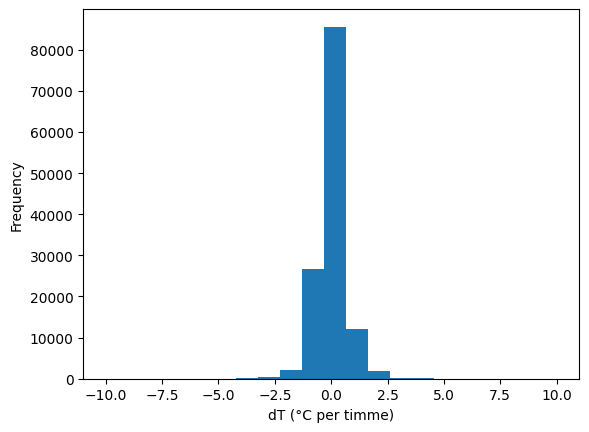

49


In [190]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('SMHI_Data.csv')

df_filled = df.copy()

print(df_filled.describe())

df_filled.drop_duplicates(subset = ["Datum", "Tid (UTC)"], inplace = True)

df_filled['Datum_Tid'] = pd.to_datetime(df_filled['Datum'] + ' ' + df_filled['Tid (UTC)'])

df_filled = df_filled.set_index('Datum_Tid')

print(df_filled.describe())

df_filled['Lufttemperatur'] = df_filled["Lufttemperatur"].interpolate(method = 'time').round(1)


### Testing only - Consider this for later as method for finding outliers via temperature change
df_filled['dT'] = df_filled["Lufttemperatur"].diff()
df_filled['dT'].plot.hist(bins=30)

plt.xlim(-11, 11)
plt.xlabel('dT (°C per timme)')
plt.show()

### ------------------------------------

count = (df_filled['dT'].abs() > 10).sum()
print(count)

Q1 = df_filled['Lufttemperatur'].quantile(0.25)
Q3 = df_filled['Lufttemperatur'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

df_filled.loc[(df_filled['Lufttemperatur'] < lower) | (df_filled['Lufttemperatur'] > upper), 'Lufttemperatur'] = np.nan

df_filled['Lufttemperatur'] = df_filled['Lufttemperatur'].interpolate(method= 'time').round(1)

df_filled = df_filled.reset_index()
df_filled = df_filled.drop(columns=['Datum_Tid'])



Question 2

Does the dataset contain any missing values? If so, how many in both absolute terms and percentages? Reflect on the number of missing values. Do you regard it as much or not?

Answer: The dataset does indeed contain missing values. Following code shows that there is 131717 rows of data with 7756 of them having missing value. Which means that the ratio of missing value is ~6%. This proportion is relatively low and
is considered managable for analysis. On important note, after observation on the CSV file itself, we can clearly see that the NaN values appears to be randomaly distributed rather than occuring in blocks, which further helps using different impution methods.



In [136]:
x = df['Lufttemperatur'].isna().sum()

y = len(df['Lufttemperatur'])

percentage = (x/y).round(4)

print(f"Total rows: {y}")
print(f"Total rows with NaN: {x}")
print(f"NaN ratio: {percentage * 100}%")

Total rows: 131717
Total rows with NaN: 7756
NaN ratio: 5.89%


Question 3

Which strategy was used for handling the missing values? Motivate why you consider the selected strategy the most suitable for this task.

Answer

We used imputation to fill our NaN values with the help of interpolation to predict what the temperature should be. We used this method over dropping the NaN values as we would have lost timestamps which we think isn't good practice in this scenario. Predicting temperature is an easier way to find "realistic" values to fill our dataset with.

Question 4

Calculate the following statistics for the air temperature values in the dataset:
• minimum value
• maximum value
• sample mean
• Q1/Q2/Q3 quartiles
• sample standard deviation
• 95% confidence interval of the mean

Answer

In [137]:
min_value = df_filled['Lufttemperatur'].min()

max_value = df_filled['Lufttemperatur'].max()
jumps = df_filled[df_filled['Lufttemperatur'].diff().abs() > 10]
print(jumps.index.tolist())


print(f'Minimum value of temperature is: {min_value}')
print(f'Maximum value of temperature is: {max_value}')

[]
Minimum value of temperature is: -12.7
Maximum value of temperature is: 31.6


Question 5

Plot all available air temperature data as a line plot with dates on the x-axis.

<Axes: xlabel='Datum'>

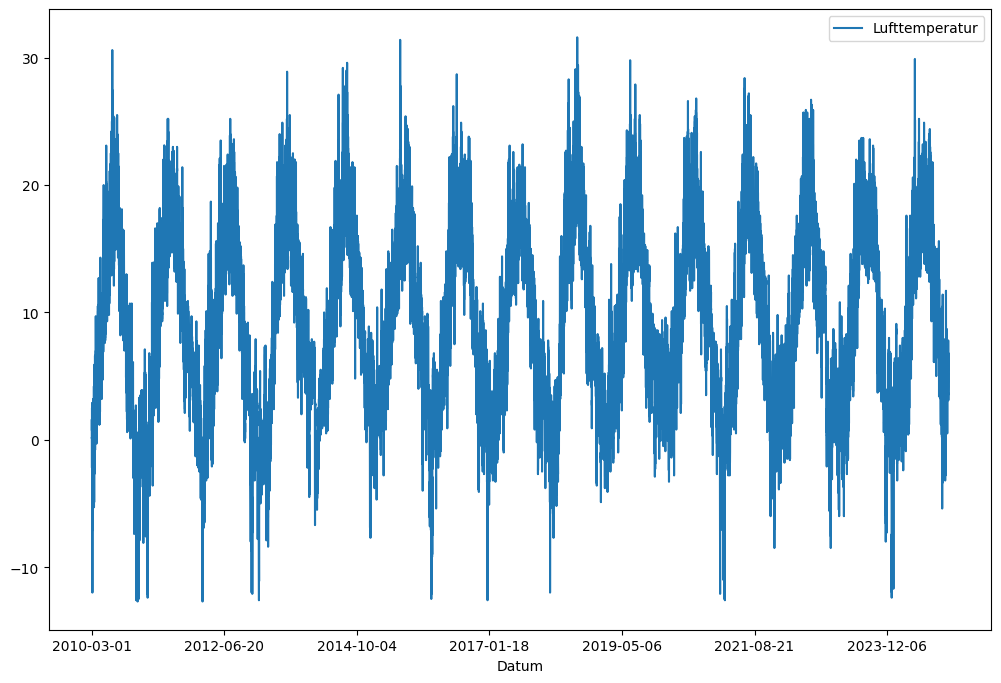

In [138]:
plt.style.use("default")
df_filled.plot.line(figsize = (12.16, 8.06), x = "Datum", y = "Lufttemperatur")

Question 6

Rank the overall temperature per month, sort from the coldest to the
warmest. List the top ten (10) coldest months in the dataset. Format the
output as: YEAR/Month: temp, e.g.“2010/January: -5.0

In [173]:
df_rank = df_filled.copy()

df_rank["Datum"] = pd.to_datetime(df_rank["Datum"])

df_rank["Year"] = df_rank["Datum"].dt.year
df_rank["Month"] = df_rank["Datum"].dt.month
df_rank["Month_name"] = df_rank["Datum"].dt.month_name()

monthly_temp = (
    df_rank.groupby(["Year", "Month", "Month_name"])["Lufttemperatur"].mean()
)

monthly_temp = monthly_temp.sort_values()

coldest_10 = monthly_temp.head(10)

for (year, month_num, month_name), temp in coldest_10.items():
    print(f"{year}/{month_name}: {temp:.1f}")

2010/December: -3.7
2011/February: -1.5
2012/February: -1.4
2021/February: -0.9
2018/February: -0.9
2016/January: -0.9
2013/March: -0.8
2013/January: -0.6
2012/December: -0.6
2013/February: -0.4


Question 7

Which distribution is suitable to consider to fit the air temperature data?
How well does the data follow that distribution given some measure, e.g., p-value?

Answer

Since the air temperature is influenced by seasons during the years, resulting a bimodal distribution with each peak for summer and winter (This is seen by plotting the data with hisogram). Therefor, a single normal distribution is not fully suitable to model the data. This helps us to identify the methods that is suitable for prediction, for example we cant really use the basic linear regression without using periodic functions. Notice that there is two histograms below where the blue represents the data before cleaning while orange represents the data after cleaning. Comparing these two helps assess whether the overall structure of the data distribution has been preserved during the cleaning process.

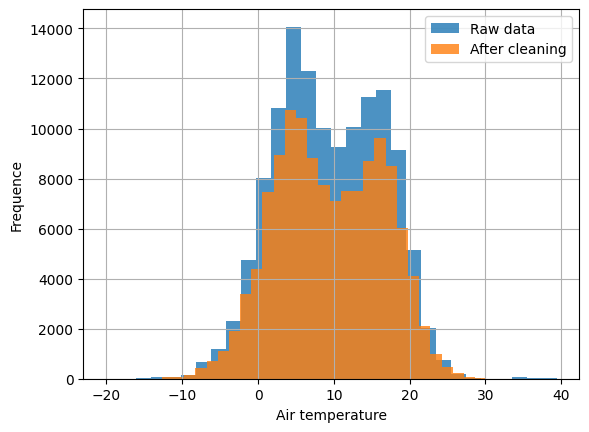

In [174]:
df["Lufttemperatur"].hist(bins = 30, alpha = 0.8, label = "Raw data")
df_filled["Lufttemperatur"].hist(bins = 30, alpha = 0.8, label = "After cleaning")
plt.legend()
plt.xlabel("Air temperature")
plt.ylabel("Frequence")
plt.show()


Question 8

Do you regard any of the air temperature measures in the dataset to
be extreme values/outliers? If so, how many values? Motivate why you
consider these values as anomalies.

Answer:

Question 9

Calculate the mean temperature for each day in the year 2024 and then
plot those means using a line plot with dates on the x-axis.

<Axes: xlabel='Datum'>

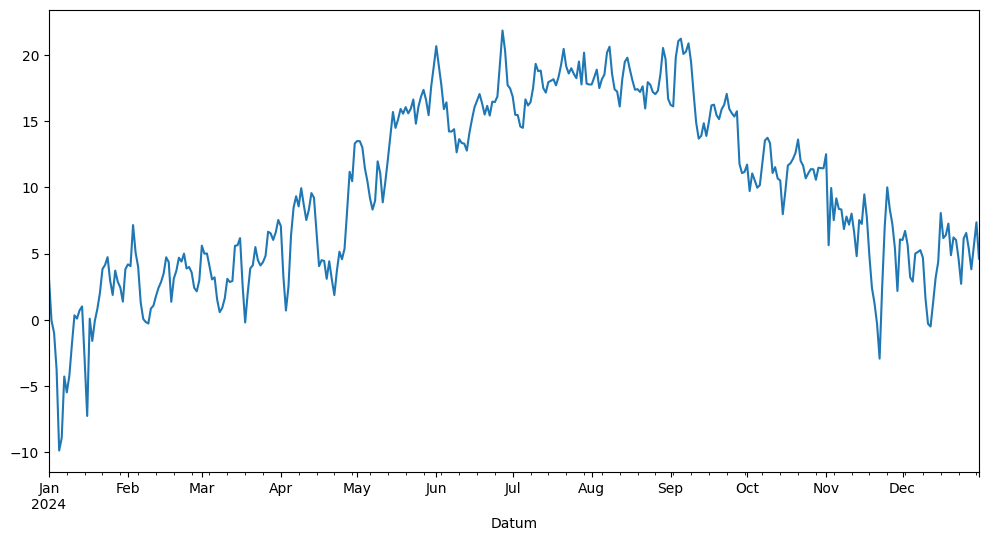

In [176]:

df_filled["Datum"] = pd.to_datetime(df_filled["Datum"])

df_filled["Year"] = df_filled["Datum"].dt.year
df_filled["Month"] = df_filled["Datum"].dt.month
df_filled["Month_name"] = df_filled["Datum"].dt.month_name()

df_filled = df_filled[df_filled["Year"] == 2024]

daily_mean = df_filled.groupby("Datum")["Lufttemperatur"].mean()

daily_mean.plot.line(figsize = (12,6), x = "Datum", y = "Lufttemperatur")


Question 10


Rank the overall temperature per two (2) consecutive months, starting with the warmest 2-month period first.

For a given year $Y_i$ and month $M_j$, compute the average temperature as:

$$
\frac{Y_i M_j + Y_i M_{j+1}}{2}
$$

including the transition between years:

$$
\frac{Y_i M_{12} + Y_{i+1} M_1}{2}
$$

This results in a sequence such as:

$$
\frac{Y_1 M_1 + Y_1 M_2}{2},\
\frac{Y_1 M_2 + Y_1 M_3}{2},\
\ldots,\
\frac{Y_1 M_{11} + Y_1 M_{12}}{2},\
\frac{Y_1 M_{12} + Y_2 M_1}{2},\
\ldots
$$

Sort all computed 2-month averages in descending order and list the ten (10) warmest 2-month periods in the dataset.

Question 11

Calculate the 95% confidence intervals (CI) for the mean of each daily
average in Q9 and add it to the line plot that shows the mean values of
each day of the year 2024. You can, for example, solve this by plotting the
upper and lower bounds as lines above and below the mean line in your
plot. Another more nicely looking solution is to visualize the CI as shades
around the mean line in your plot